# Florence Airbnb – Model Notebook

In this notebook we build and evaluate models to predict Airbnb prices in Florence using the engineered dataset `listings_features.csv`.

We go step by step:

1. **Baseline k‑NN** using only location (latitude & longitude).  
2. **Baseline Gradient Boosting (XGBoost)** using all features.  
3. A **hybrid model** that combines k‑NN spatial information with gradient boosting.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.neighbors import NearestNeighbors

data = pd.read_csv('data/listings_features.csv')

## 1. Baseline k‑NN (location only)

We start with a simple baseline: a k‑Nearest Neighbours regressor that uses only latitude and longitude to predict price (log‑transformed). This tells us how much of the price variation can be explained by **location alone**.

### 1.1 Target variable

We predict the nightly price of a listing. Because raw prices are highly right‑skewed, we predict the **log‑transformed price** instead:

\[
y = \log(1 + \text{price})
\]

Using log‑price stabilizes variance and makes errors more comparable between cheap and expensive listings. Predictions are exponentiated back to euros for evaluation and interpretation.

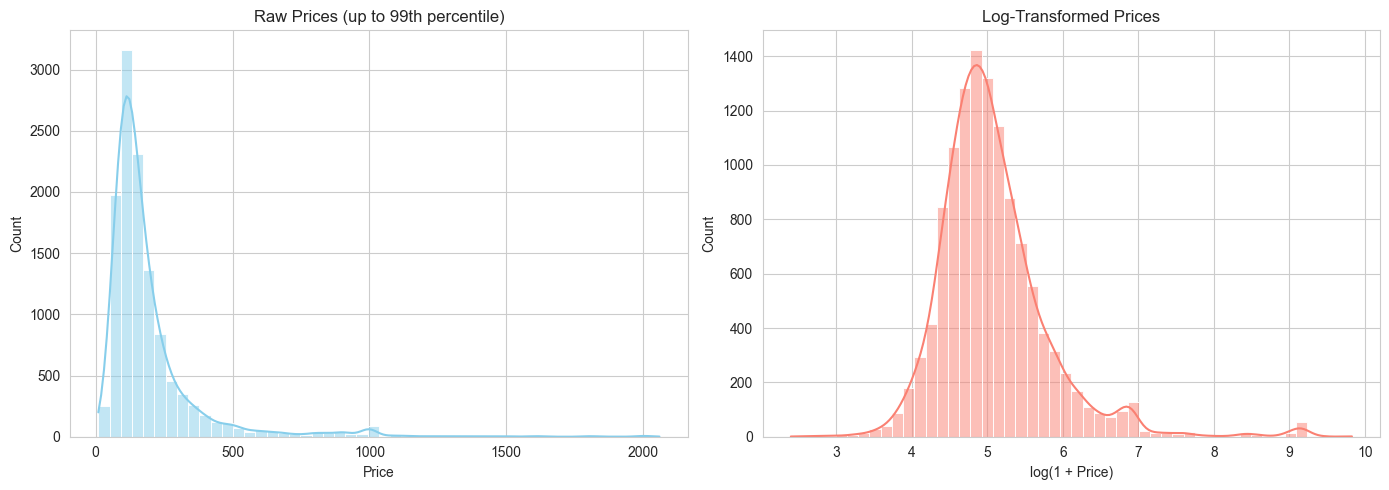

In [4]:
price = data['price']
# log-transform
log_price = np.log1p(price)

upper = price.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(price[price <= upper], bins=50, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Raw Prices (up to 99th percentile)")
axes[0].set_xlabel("Price")

sns.histplot(log_price, bins=50, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Log-Transformed Prices")
axes[1].set_xlabel("log(1 + Price)")

plt.tight_layout()
plt.show()

The raw Airbnb price distribution is strongly right-skewed, with a long tail of very expensive listings. After applying a log transformation, the distribution becomes more symmetric, which helps stabilize model training and makes prediction errors less dominated by a few extreme prices.

In [7]:
y = log_price

### 1.2 Features for k‑NN

For the k‑NN baseline we use only the listing’s **geographical position**:

- `latitude`  
- `longitude`

These two features are extracted from the cleaned feature table:

- We do **not** include any additional information (beds, amenities, reviews, etc.) here – the point is to see how far we can get with location alone.

In [8]:
X_knn = data[['latitude', 'longitude']].copy()

### 1.3 Model creation 

#### 1.3.1 Choosing the number of neighbours \(k\)

We treat \(k\) as the main hyperparameter of the k‑NN model. To select a good value we:

1. Loop over candidate values \(k = 1, 2, \dots, 40\).  
2. For each \(k\), train a k‑NN regressor on the training set and compute **validation RMSE** on log‑price.  
3. Plot validation RMSE versus \(k\) (elbow plot).  
4. Additionally, plot **training and validation RMSE vs. \(k\)** to visualize the bias–variance trade‑off.

In [9]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_knn, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)


In [ ]:
k_values = range(1, 40)   # you can adjust the range
rmse_scores = []

for k in k_values:
    knn_reg = KNeighborsRegressor(n_neighbors=k, weights='distance')
    knn_reg.fit(X_train_scaled, y_train)
    y_valid_pred_log = knn_reg.predict(X_valid_scaled)

    # Compute RMSE on log-price (or convert back to price if you prefer)
    mse  = mean_squared_error(y_valid, y_valid_pred_log)
    rmse = np.sqrt(mse)
    rmse_scores.append(rmse)

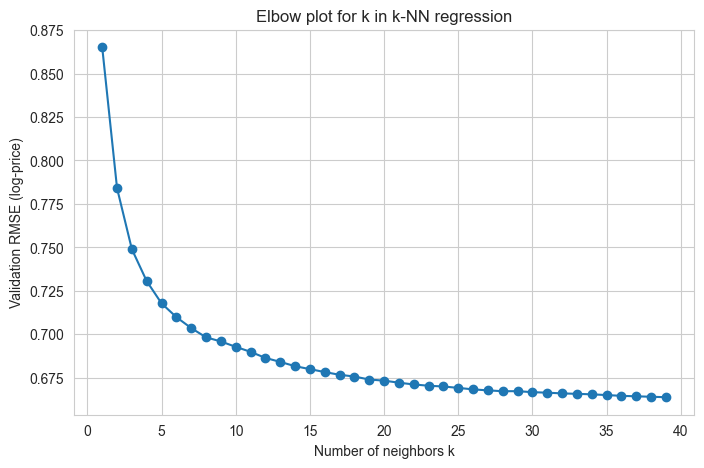

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, rmse_scores, marker='o')
plt.xlabel("Number of neighbors k")
plt.ylabel("Validation RMSE (log-price)")
plt.title("Elbow plot for k in k-NN regression")
plt.grid(True)
plt.show()

Qualitative observations:

- For very small \(k\) (e.g. 1–2), the model fits the training data extremely well but shows high validation error → high variance / overfitting.  
- As \(k\) increases, validation RMSE drops quickly up to roughly \(k \approx 8–10\), then flattens.  
- For large \(k\), the model becomes a very smooth spatial average; validation RMSE and MAE change only slightly.

From these plots we conclude that any \(k\) in the range **8–12** offers a good trade‑off between bias and variance. For the rest of the analysis we fix **\(k = 10\)** as our final choice, since it lies near the elbow and keeps the notion of a “local neighbourhood” intuitive.

#### 1.3.2 Train / validation / test split and scaling

We split the dataset into three disjoint subsets:

- **Train set** (70 %) – used to fit the k‑NN model and to select hyperparameters.  
- **Validation set** (15 %) – used to tune the number of neighbors \(k\) and to inspect the bias–variance trade‑off.  
- **Test set** (15 %) – held out until the end, used only once to report final performance.

Because k‑NN is distance‑based, we standardize the coordinates:

- Fit a `StandardScaler` on the **training** latitude/longitude.  
- Apply the same transformation to validation and test sets.  

This keeps the distance computation well‑behaved and avoids data leakage from validation/test into training.

In [ ]:
# First split: train vs temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_knn, y, test_size=0.3, random_state=42
)

# Second split: temp into valid and test
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Scale using ONLY train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled  = scaler.transform(X_test)

# Fit k-NN with your chosen k
knn_reg = KNeighborsRegressor(n_neighbors=10, weights='distance')
knn_reg.fit(X_train_scaled, y_train)


Validation RMSE: 708.9211266248509
Validation MAE : 151.8714352745526
Test RMSE      : 937.7637882414587
Test MAE       : 180.78044822234915


#### 1.3.3 Testing

Finaly the Model is tested and evalueted.

In [ ]:
# 1. Predict log-prices
y_valid_pred_log = knn_reg.predict(X_valid_scaled)
y_test_pred_log  = knn_reg.predict(X_test_scaled)

# 2. Back to price scale
y_valid_true = np.expm1(y_valid)          # true prices
y_test_true  = np.expm1(y_test)
y_valid_pred = np.expm1(y_valid_pred_log) # predicted prices
y_test_pred  = np.expm1(y_test_pred_log)

# 3. Validation metrics (on price scale)
mse_valid  = mean_squared_error(y_valid_true, y_valid_pred)
rmse_valid = np.sqrt(mse_valid)
mae_valid  = mean_absolute_error(y_valid_true, y_valid_pred)

# 4. Test metrics (on price scale)
mse_test  = mean_squared_error(y_test_true, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test  = mean_absolute_error(y_test_true, y_test_pred)

print("Validation RMSE:", rmse_valid)
print("Validation MAE :", mae_valid)
print("Test RMSE      :", rmse_test)
print("Test MAE       :", mae_test)

Our k‑NN baseline using only geographic coordinates achieves a validation RMSE of about 709 € and MAE of 152 €, and a test RMSE of about 938 € and MAE of 181 €. This indicates that, on average, predictions are off by around 150–180 € per listing, which is relatively large compared to typical Airbnb prices, so we expect more complex models such as gradient boosting to provide substantial improvements.

## 2. Model Choice: Gradient Boosting

Either XGBoost or Catboost

### Target
Log scaled see above

In [30]:
data.columns

Index(['id', 'neighbourhood_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights',
       'number_of_reviews', 'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'review_scores_missing',
       'bathrooms_text_missing', 'bath_shared', 'bath_private_flag',
       'bath_half', 'description_missing', 'description_len_chars',
       'description_len_words', 'desc_kw_luxury', 'desc_kw_modern',
       'desc_kw_spacious', 'desc_kw_cozy', 'desc_kw_quiet', 'desc_kw_charming',
       'desc_kw_bright', 'desc_kw_stylish', 'desc_kw_elegant',
       'desc_kw_unforgattable', 'desc_kw_relaxing',
       'desc_kw_everything you need', 'desc_kw_cute', 'desc_kw_comfortable',
       'neighborhood_overview_missing', 'nb_overvi

### Features
Numeric: latitude, longitude, accommodates, bathrooms, bedrooms, beds, minimum_nights, maximum_nights, number_of_reviews, review_scores_rating, review_scores_accuracy, review_scores_cleanliness, review_scores_checkin, review_scores_communication, review_scores_location, review_scores_value, description_len_chars, description_len_words, nb_overview_len_chars, nb_overview_len_words, am_score_kitchen, am_score_bath_toiletries, am_score_comfort, am_score_safety, am_score_laundry_cleaning, am_score_workspace, amenities_count

Boolean/Flags: review_scores_missing, bathrooms_text_missing, bath_shared, bath_private_flag, bath_half, description_missing,
desc_kw_luxury, desc_kw_modern, desc_kw_spacious, desc_kw_cozy, desc_kw_quiet, desc_kw_charming, desc_kw_unforgattable, desc_kw_relaxing, desc_kw_everything_you_need, desc_kw_cute, desc_kw_comfortable, neighborhood_overview_missing, nb_cat_transport, nb_cat_food_places, nb_cat_shops, nb_cat_sights, nb_cat_nightlife, nb_cat_greener, nb_cat_quiet_residential, 
am_wifi, am_hotwater, am_kitchen, am_heating, am_air_conditioning, am_tv, am_bidet, am_parking, am_housekeeping

Categorical: neighbourhood_cleansed, property_type, room_type


## 3. Hybrid Model: 